In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df1 = pd.read_csv('/Users/smasarone/Desktop/MOGONET/top_features_.csv')
df2 = pd.read_csv('/Users/smasarone/Desktop/MOGONET/top_features_2.csv')
df3 = pd.read_csv('/Users/smasarone/Desktop/MOGONET/top_features_3.csv')
df4 = pd.read_csv('/Users/smasarone/Desktop/MOGONET/top_features_4.csv')
df5 = pd.read_csv('/Users/smasarone/Desktop/MOGONET/top_features_5.csv')

In [3]:
## What questions do we want to ask
## 1) what are the most occurring biomarkers?
## 2) do we see the same proteins that we see in the other model? (keep in mind that here we have more features so it's a different set)
## 3) does the model favor any particular data type (0,1,2)?
## 4) biological insight that we get for every iteration (where do these proteins belong?)-pathways
## 5) does this help the field of trauma? In what way?

## Other things to consider with integration 

In [4]:
df1 = df1[df1['imp']>0.0]
df2 = df2[df2['imp']>0.0]
df3 = df3[df3['imp']>0.0]
df4 = df4[df4['imp']>0.0]
df5 = df5[df5['imp']>0.0]

final_list_with_rep=[]
datasets = [df1, df2, df3, df4, df5]
for i in datasets:
    final_list_with_rep.append(list(i['feat_name']))


#now flatten the list to check how many times a protein appears
#flattened = [word for sublist in final_list_with_rep for word in sublist]
flattened =[]
for sublist in final_list_with_rep:
    for word in sublist:
        flattened.append(word)

len(df1)+len(df2)+len(df3)+len(df4)+len(df5) # with repetition

221

In [5]:
dict_={}
for i in flattened:
    if i not in dict_.keys():
        dict_[i]=1
    elif i in dict_.keys():
        dict_[i]= dict_[i]+1

# turn this into a df with frequencies
freq_df = pd.DataFrame(dict_.keys(), columns =['name'])
freq_df['frequency'] = dict_.values()
freq_df['name_only'] = freq_df['name'].apply(lambda x: x.split(".")[0])
freq_df.shape

(156, 3)

In [6]:
# 1) the most occurring proteins belong to metabolic pathways and are associated to covid/metabolism
freq_df.sort_values('frequency', ascending=False)[0:10]

,name,frequency,name_only
0,ADGRG3,4,ADGRG3
5,APMAP,4,APMAP
15,EEF1D.17826.341,4,EEF1D
1,MED25,4,MED25
7,PCNX1,4,PCNX1
14,ALOX5AP,4,ALOX5AP
2,ATP11B,4,ATP11B
4,CSGALNACT2,4,CSGALNACT2
53,GPAT4,3,GPAT4
20,SRPK1,3,SRPK1


In [7]:
for i in freq_df[freq_df['frequency']>=3]['name']:
    print(i) 

### they appear in the downregulated genes for covid infection #GSE161731 dataset regardless of the selection 
### we make frequency either 2, 3 or 4

ADGRG3
MED25
ATP11B
CSGALNACT2
APMAP
PCNX1
AGAP2
ALOX5AP
EEF1D.17826.341
WSB1
ADAP2
SRPK1
GPAT4


### Plot frequency

In [8]:
#c0afec    # purple
#edacac    # pink
#bcf9a7    # green
palette_chapter = sns.color_palette(["#f18585", "#7fdf5c"])
palette_chapter

[(0.9450980392156862, 0.5215686274509804, 0.5215686274509804),
 (0.4980392156862745, 0.8745098039215686, 0.3607843137254902)]

In [11]:
man_num=25

# plt.figure(figsize = (10, 7))
# top_biom = freq_df.sort_values('frequency', ascending=False)['name'][0:man_num]
# data_type = ["Gene" if "." not in i else "Protein" for i in top_biom]
# ax = sns.barplot(x = freq_df.sort_values('frequency', ascending=False)['name'][0:man_num], 
#             y= freq_df.sort_values('frequency', ascending=False)['frequency'][0:man_num], 
#             color = '#c0afec', alpha=0.2, edgecolor='#c0afec')

# sns.scatterplot(x = freq_df.sort_values('frequency', ascending=False)['name'][0:man_num], 
#                 y = freq_df.sort_values('frequency', ascending=False)['frequency'][0:man_num], 
#                 hue = data_type,
#                 palette=palette_chapter, alpha = 1)

# ax.set_xticklabels(freq_df.sort_values('frequency', ascending=False)['name_only'][0:man_num], 
#                    rotation = 45,
#                    ha='right')
# plt.title("Biomarker frequency")
# image_name = '/Users/smasarone/Downloads/biom_frequency.pdf'
# plt.savefig(image_name, dpi=1200, bbox_inches='tight') 

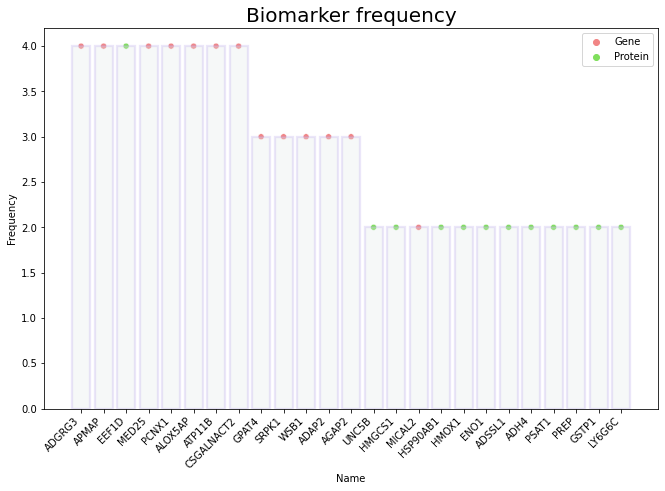

In [12]:
plt.figure(figsize = (11, 7))
top_biom = freq_df.sort_values('frequency', ascending=False)['name'][0:man_num]
data_type = ["Gene" if "." not in i else "Protein" for i in top_biom]
ax = sns.barplot(x = freq_df.sort_values('frequency', ascending=False)['name'][0:man_num], 
            y= freq_df.sort_values('frequency', ascending=False)['frequency'][0:man_num], 
            color = '#e2eaec', alpha=0.3, edgecolor='#c0afec')

sns.scatterplot(x = freq_df.sort_values('frequency', ascending=False)['name'][0:man_num], 
                y = freq_df.sort_values('frequency', ascending=False)['frequency'][0:man_num], 
                hue = data_type,
                palette=palette_chapter, alpha = 1)

ax.set_xticklabels(freq_df.sort_values('frequency', ascending=False)['name_only'][0:man_num], 
                   rotation = 45,
                   ha='right')
plt.setp(ax.patches, linewidth=2.3)
plt.title("Biomarker frequency", fontdict={'fontsize': 20})
plt.xlabel("Name")
plt.ylabel("Frequency")

image_name = '/Users/smasarone/Downloads/biom_frequency.pdf'
plt.savefig(image_name, dpi=1200, bbox_inches='tight') 

### 1-5) Pathways they belong to

In [13]:
# KEGG 2021
import enrich_omics
from enrich_omics import EnrichR

# get pathways for all features (top 50 for all models with importace >0, total of 156)
gene_list = freq_df['name_only']
EnrichR.plot_enrichment(gene_list, max_hits=10)

alt.LayerChart(...)

In [239]:
len(gene_list)

156

In [240]:
#plot top 30
top_most_occu = freq_df.sort_values('frequency', ascending=False)[0:30]['name_only']
EnrichR.plot_enrichment(top_most_occu, max_hits=15)

alt.LayerChart(...)

1) The most occurring biomarkers are proteins from metabolic pathways, glycolysis and gluconeogenesis. In addition, we have proteins belonging to fatty acid degradation and pyruvate metabolism.
They seem to all originate from similar processes. If we look at the top 30 most occurring biomarkers across all models iterations we can see that we still see mostly metabolic pathways involved as well as HIF-1 ginalling pathway. It seems like they all belong to the same metabolic pathways regardless of the filtering we apply. This suggests that overall metabolic proteins help discriminate criitcal patients from less critical ones.

### 2) clusters they belong to, are they the same as before?

In [241]:
### Import the table with the proteins belonging to every cluster
prot_df = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/labels_labels.csv', index_col= 0)
prot = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/dataset_final_4979prot.csv', index_col = 0)
col_idx = prot.columns

prot_df.index = col_idx
prot_df['idx'] = prot_df.index
new_i=[]
for i in prot_df['idx']:
    new_i.append(i.split(".")[0])
prot_df['name_only'] = new_i

prot_df.head(3)

,0,idx,name_only
A1BG.16561.9,19,A1BG.16561.9,A1BG
A1CF.12423.38,14,A1CF.12423.38,A1CF
A2M.3708.62,8,A2M.3708.62,A2M


### CLUSTERS

In [249]:
# different filtering (ALL)
# we are treating both like the same and so we are dropping duplicates

prot_df_ = prot_df.drop_duplicates(subset=['name_only'])
clusters_sel2 = prot_df_.filter(freq_df['name'],axis = 0)
print(len(clusters_sel2))
clusters_sel2.iloc[:,0].value_counts(normalize = True)

91


17    0.637363
2     0.307692
9     0.032967
19    0.021978
Name: 0, dtype: float64

In [245]:
## PROTEINS ONLY
clusters_sel = prot_df.filter(freq_df['name'],axis = 0)
clusters_sel.columns = ['cluster', 'idx', 'name_only']
print(len(clusters_sel))
clusters_sel['cluster'].value_counts(normalize=True)

94


17    0.627660
2     0.297872
19    0.031915
9     0.031915
18    0.010638
Name: cluster, dtype: float64

In [246]:
### GENES only
genes=[]
for i in freq_df['name']:
    if "." not in i:
        genes.append(i)
assert len(genes) == 58

# find the corresponding prot idx for them
indices=[]
for i in prot_df_.index:
    if prot_df_.loc[i,'name_only'] in genes:
        indices.append(i)
print("we only find these:", len(indices), 'genes')

clusters_sel3 = prot_df_.filter(indices,axis = 0)
clusters_sel3.columns = ['cluster', 'idx', 'name_only']
indices
clusters_sel3['cluster'].value_counts()

we only find these: 22 genes


3     5
14    5
7     3
6     2
11    2
18    2
9     1
17    1
15    1
Name: cluster, dtype: int64

In [247]:
# so instead since we don't have most of them, we can run this to check what they do

EnrichR.plot_enrichment(genes, max_hits=15)

alt.LayerChart(...)

In [248]:
## if we sort on frequency only the first 20
sorted_df = freq_df.sort_values(by ='frequency', ascending=False)[0:100]
top_50 = prot_df_.filter(sorted_df['name'],axis = 0)
top_50.columns = ['cluster', 'idx', 'name_only']
top_50['cluster'].value_counts(normalize=True) 

17    0.767442
2     0.232558
Name: cluster, dtype: float64

2) We see the same clusters being highlighted by these models as well. When we check what clusters the proteins belong to, we can see that most of them belong to cluster 17 (0.62) and 2 (0.29) and 19 (0.3). If we narrow down the number of proteins to the top 20, we can see that they belong to cluster 17, 2 and 18.

This suggests that the model is identifying similar protein and genes to the ones identified by the previous model confirming those results. We still see a prevalence of proteins belonging to cluster 17/2 as they are the most differentially expressed between patients eith different severity levels.

### 3) Preferred data type?

[98 58]


<AxesSubplot:title={'center':'Features from each data type - overall'}>

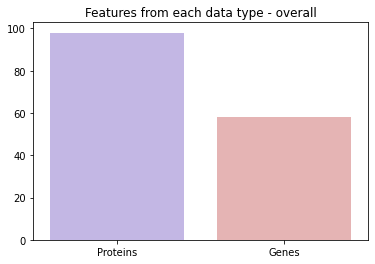

In [86]:
### check if framework favours any particular data type (all features considered)
data_type=[]
for i in freq_df['name']:
    if "." in i:
        data_type.append(0)
    else:
        data_type.append(1)
freq_df['data_type'] = data_type

## it seems like there are more proteins than genes selected by the model
print(np.bincount(data_type))
plt.title("Features from each data type - overall")
sns.barplot(x =["Proteins","Genes"], y = np.bincount(data_type), palette = palette_chapter)

In [78]:
98/(98+58)

0.6282051282051282

In [79]:
1/3

0.3333333333333333

In [80]:
top=20
df1_top = df1.head(top)
df2_top = df2.head(top)
df3_top = df3.head(top)
df4_top = df4.head(top)
df5_top = df5.head(top)

final_top = df1_top.append(df2_top).append(df3_top).append(df4_top).append(df5_top)

/var/folders/qj/tdp1dq2138jdytx50m9g6p180000gr/T/ipykernel_77951/2820224205.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final_top = df1_top.append(df2_top).append(df3_top).append(df4_top).append(df5_top)
/var/folders/qj/tdp1dq2138jdytx50m9g6p180000gr/T/ipykernel_77951/2820224205.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final_top = df1_top.append(df2_top).append(df3_top).append(df4_top).append(df5_top)
/var/folders/qj/tdp1dq2138jdytx50m9g6p180000gr/T/ipykernel_77951/2820224205.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final_top = df1_top.append(df2_top).append(df3_top).append(df4_top).append(df5_top)
/var/folders/qj/tdp1dq2138jdytx50m9g6p180000gr/T/ipykernel_77951/2820224205.py:8: FutureWarning: 

<AxesSubplot:title={'center':'Features from each data type by importance'}>

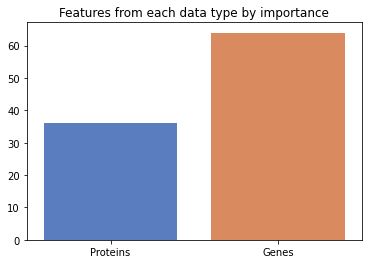

In [87]:
# only taking the top ones from each model
np.bincount(final_top['omics'])

np.bincount(data_type)
plt.title("Features from each data type by importance")
sns.barplot(x =["Proteins","Genes"], y = np.bincount(final_top['omics']), palette = 'muted')

In [82]:
# the proteins selected by our models (top only!)
gene_list = final_top[final_top['omics']==1]['feat_name']
EnrichR.plot_enrichment(gene_list, max_hits=10)

alt.LayerChart(...)

In [83]:
# the genes selected by our models (top only)
gene_list = final_top[final_top['omics']==0]['feat_name']
new = [i.split(".")[0] for i in gene_list]

EnrichR.plot_enrichment(new, max_hits=10)

alt.LayerChart(...)

3)Looking at all the features selected by our framework in all iterations (we selected the top 50 for each split), we can see that about 2/3 thirds are from the proteomics while 1/3 from the transcriptomics. This analysis does not take into account importance of the feature but it's an overall view. If we look at specific models and we select the top 20 most important features by model, we observe that 36% of them are proteins while 64 are genes. This suggests thatthere seems to be a subset of genes that have been picked up as relevant for the prediction. 

4) metabolism and HIF1 - signalling pathways!

### RESULTS!!

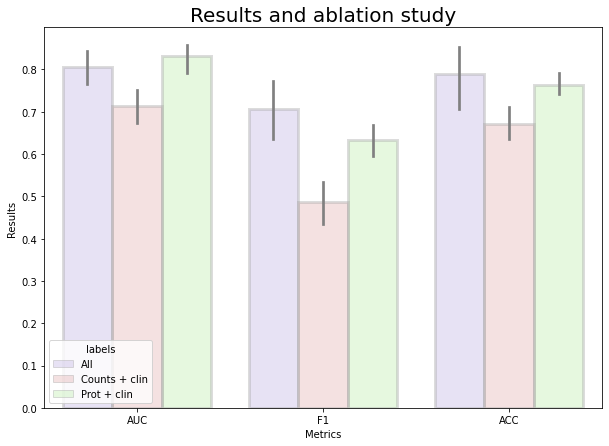

In [209]:
# test results
#all, no prot, no counts
palette_chapter = sns.color_palette(["#c0afec", "#edacac", "#bcf9a7"])
palette2 = sns.color_palette(["#A8BFC6", "#c6d5da", "#f6f8f9"])


plt.figure(figsize = (10, 7))
AUC =[0.836, 0.778, 0.796, 0.876, 0.745, 0.759, 0.75, 0.737, 0.647, 0.67, 0.865, 0.85, 0.85, 0.839, 0.756]
F1 = [0.772, 0.796, 0.679,0.704,0.576, 0.571, 0.484, 0.509, 0.40, 0.468, 0.639, 0.646, 0.689, 0.571, 0.618]
ACCU =[0.87 ,0.644, 0.835,0.845,0.757, 0.68, 0.689, 0.738, 0.65, 0.602, 0.748, 0.777, 0.816, 0.738, 0.74]
labels = ['All']*5+['Counts + clin']*5+ ['Prot + clin']*5+['All']*5 +['Counts + clin']*5+ ['Prot + clin']*5+['All']*5+['Counts + clin']*5+ ['Prot + clin']*5

metrics = AUC+F1+ACCU
names_metrics = ['AUC']*15+["F1"]*15+["ACC"]*15
met_df = pd.DataFrame(metrics, columns = ['results'])
met_df['metric_name'] = names_metrics
met_df['labels'] = labels

plt.title("Results and ablation study", fontdict={'fontsize': 20})
ax = sns.barplot(data=met_df, x = 'metric_name', 
            y = 'results', 
            hue = 'labels', 
            alpha = 0.4,
            color = 'white',
            palette = palette_chapter,
            edgecolor='darkgrey',
            errcolor='.5')
plt.setp(ax.patches, linewidth=3)
plt.xlabel("Metrics")
plt.ylabel("Results")
image_name = '/Users/smasarone/Downloads/aucs.pdf'
plt.savefig(image_name, dpi=1200, bbox_inches='tight')


<AxesSubplot:xlabel='metric_name', ylabel='results'>

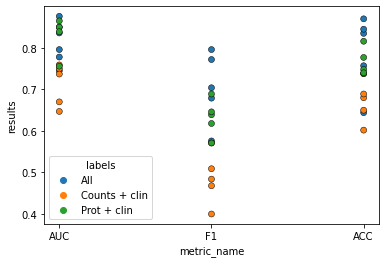

In [152]:
sns.scatterplot(x = met_df['metric_name'], 
            y = met_df['results'], 
            hue = met_df['labels'], 
            alpha = 1,
            color = color,
            edgecolor='black')


5) what does it tell us? (Maybe some ablation study would help?)
From the ablation study we can see that even if some of the features that are selected by the model are genes and some of them are considered top features, when we remove the transcriptomics we obtan a better AUC compared to when we use transcriptomics as well. In addition, removing the counts results in a better AUC, ACC and F1 score compared to the removal of proteomics. Overall this suggests that the proteomics alone provide more information compared to the transcriptomics at this early stage. We had seen this experimentally before but confirmed it here

In [144]:
mean_model = np.mean([0.836, 0.778, 0.796, 0.876, 0.745])
std = np.std([0.836, 0.778, 0.796, 0.876, 0.745])
mean_model, std

(0.8061999999999999, 0.04561754048608933)

In [99]:
# accu
mean_model = np.mean([0.759, 0.75, 0.737, 0.647, 0.67])
std = np.std([0.759, 0.75, 0.737, 0.647, 0.67])
mean_model, std

(0.7125999999999999, 0.04531048443793113)

In [98]:
mean_model = np.mean([0.865, 0.85, 0.85, 0.839, 0.756])
std = np.std([0.865, 0.85, 0.85, 0.839, 0.756])
mean_model, std

(0.8320000000000001, 0.03888958729531594)